In [ ]:
# 英文名: Advanced-Fraud-Detection-with-Unsupervised-and-Graph-Learning
# 中文名: 基于无监督学习与图神经网络的进阶反欺诈检测系统
# 关键词: Unsupervised (无监督), Graph Learning (图学习), Anomaly Detection (异常检测), Semi-supervised (半监督).

In [1]:
# 场景：信用卡盗刷检测 / 注册环节的黑产识别 / 交易反欺诈。
# 痛点：黑样本极少（占比<1%），且新型欺诈手段层出不穷，传统监督学习失效。
# 方案：采用“无监督异常检测 + 半监督学习”的组合策略。

<big>IsolationForest LocalOutlierFactor SelfTrainingClassifier networkx<big>

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# 基础路径
base_path = Path(r"C:\Users\田\Desktop\python实操\git hub\Credit Card Fraud Detection")  # 你的原始路径

In [3]:
creditcard = pd.read_csv(base_path / 'creditcard.csv')

In [4]:
creditcard

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
creditcard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
creditcard['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

<big>scaler<big>

In [7]:
X_all=creditcard.drop('Class',axis=1)
y_true = creditcard[['Class']]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X_all)

In [9]:
feature_add = pd.DataFrame()

<big>IsolationForest<big>

In [10]:
%%time
from sklearn.ensemble import IsolationForest
clf_if = IsolationForest(contamination=0.0005, random_state=42, n_estimators=100)
clf_if.fit(X_all) 

CPU times: total: 2.02 s
Wall time: 2.1 s


IsolationForest(contamination=0.0005, random_state=42)

In [11]:
feature_add['scores_if'] = clf_if.decision_function(X_all) # 值越小越异常

<big>LocalOutlierFactor<big>

In [12]:
%%time
from sklearn.neighbors import LocalOutlierFactor

clf_lof = LocalOutlierFactor(n_neighbors=15, contamination='auto', novelty=True,)
clf_lof.fit(X1_scaled)

  File "C:\anaconda\envs\py312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\anaconda\envs\py312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda\envs\py312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\anaconda\envs\py312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


CPU times: total: 10min 9s
Wall time: 40.6 s


LocalOutlierFactor(n_neighbors=15, novelty=True)

In [13]:
%%time
feature_add['scores_lof']  = -clf_lof.score_samples(X1_scaled)

CPU times: total: 10min 10s
Wall time: 41 s


<big>SelfTrainingClassifier<big>

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_full, y_test = train_test_split(
    X1_scaled, y_true, test_size=0.3, random_state=42,stratify=y_true,
)

In [15]:
y_empty = np.full((len(X_test), y_train_full.shape[1]), -1)
y_train = np.concatenate([y_train_full, y_empty])

In [16]:
%%time
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier
from sklearn.ensemble import RandomForestClassifier

base_clf = RandomForestClassifier(random_state=42,n_jobs=-1,class_weight='balanced',oob_score =True)
self_training_model = SelfTrainingClassifier(base_clf, 
                                             threshold=0.75,  # 置信度阈值
                                             k_best=10,       # 每次选择top-k
                                             max_iter=10)     # 最大迭代次数
self_training_model.fit(X1_scaled, y_train)
feature_add['scores_sl'] = self_training_model.predict_proba(X1_scaled)[:, 1]

CPU times: total: 11min 34s
Wall time: 55.6 s


<big>networkx<big>

In [17]:
%%time
import networkx as nx
from sklearn.neighbors import NearestNeighbors

df=X1_scaled

# 数据准备
if isinstance(df, pd.DataFrame):
    features = ['V1','V2','V3','V4','V5','Amount']
    X = df[features].values
else:
    X = df[:, :6]

n_samples = len(X)
print(f"Processing {n_samples} samples...")

# 1. 全量构建 KNN (kd_tree 在低维数据最快)
k = 10
knn = NearestNeighbors(n_neighbors=k+1, algorithm='kd_tree', n_jobs=-1)
knn.fit(X)
distances, indices = knn.kneighbors(X)

# 2. 构建图 (仅添加单向边避免重复)
G = nx.Graph()
G.add_nodes_from(range(n_samples))
edges = []
for i in range(n_samples):
    neighbors = indices[i, 1:] 
    for neighbor in neighbors:
        if i < neighbor:
            edges.append((i, neighbor))

print(f"Adding {len(edges)} edges to graph...")
G.add_edges_from(edges)

# 3. 计算异常分数 (KNN 平均距离)
feature_add['scores_nx'] = distances[:, 1:].mean(axis=1)

Processing 284807 samples...
Adding 1429191 edges to graph...
CPU times: total: 57.5 s
Wall time: 9.31 s


In [29]:
%%time
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

# 数据准备
if isinstance(df, pd.DataFrame):
    features = ['V1','V2','V3','V4','V5','Amount']
    X = df[features].values
else:
    X = df[:, :6]

n_samples = len(X)
print(f"Building Graph for {n_samples} samples...")

# 1. 构建 KNN 图
k = 8 # 邻居数不宜过大，否则所有点都连成一片，无法区分小团伙
knn = NearestNeighbors(n_neighbors=k+1, algorithm='kd_tree', n_jobs=-1)
knn.fit(X)
distances, indices = knn.kneighbors(X)

# 2. 创建图并添加边
G = nx.Graph()
G.add_nodes_from(range(n_samples))

# 优化：直接向列表添加边，比循环 add_edge 快
edges = []
for i in range(n_samples):
    # 只连接距离小于某个阈值的邻居，防止长边把孤立点强行连入大网
    # 这里简单策略：只连前 k 个
    for j in range(1, k+1):
        neighbor = indices[i, j]
        if i < neighbor:
            edges.append((i, neighbor))

G.add_edges_from(edges)
print(f"Graph built with {G.number_of_edges()} edges.")

# 3. 【核心图算法】计算连通分量大小
# 这一步是纯图论操作，之前的代码没有做
component_map = {}
for i, component in enumerate(nx.connected_components(G)):
    comp_size = len(component)
    for node in component:
        component_map[node] = comp_size

# 将图特征转换为数组
comp_sizes = np.array([component_map[i] for i in range(n_samples)])

# 4. 构造综合异常分数
# 逻辑：分量越小越异常 (取倒数)，距离越大越异常
# 归一化距离 (可选，防止量纲影响)
mean_distances = distances[:, 1:].mean(axis=1)
max_dist = mean_distances.max()
norm_distances = mean_distances / (max_dist + 1e-9)

# 综合得分：小分量 (1/size) + 大距离
# 注意：正常点 size 可能几万，倒数接近 0；异常点 size=1~5，倒数较大
# feature_add_1['scores_nx1']
graph_score = (1.0 / comp_sizes) + norm_distances 

feature_add['scores_nx1'] =graph_score 

# 5. 阈值判定
threshold = np.percentile(graph_score, 99.8)
predictions = (graph_score > threshold).astype(int)

Building Graph for 284807 samples...
Graph built with 1143053 edges.
CPU times: total: 59.7 s
Wall time: 9.07 s


In [31]:
import matplotlib.pyplot as plt
# 寻找连通子图 (Connected Components) -> 潜在的欺诈团伙
components = list(nx.connected_components(G))
print(f"发现 {len(components)} 个潜在团伙，其中最大团伙包含 {len(max(components, key=len))} 人")

发现 157 个潜在团伙，其中最大团伙包含 284214 人


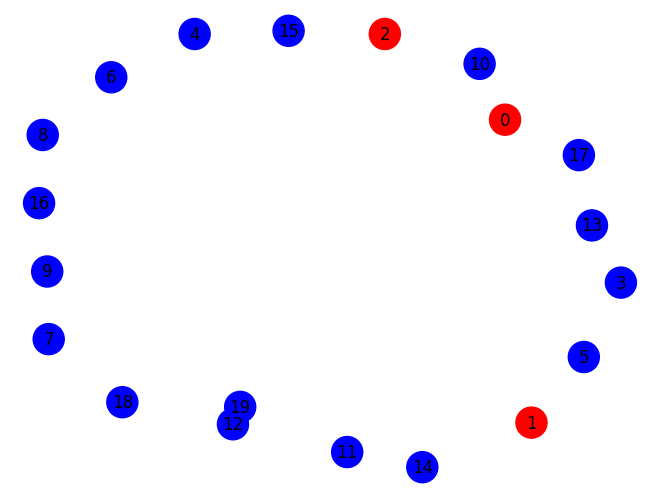

In [33]:
# 可视化一个小团伙
if len(components) > 0:
    sub_g = G.subgraph(list(components[0])[:20]) # 取前20人画图
    node_colors = ['red'] * 3 + ['blue'] * (len(sub_g.nodes()) - 3)
    nx.draw(sub_g, with_labels=True, node_color=node_colors, node_size=500)
    plt.show()

In [34]:
feature_add

,scores_if,scores_lof,scores_sl,scores_nx,scores_nx1
0,0.317709,1.094726,0.0,0.366902,0.005312
1,0.316418,1.730611,0.0,0.111064,0.001643
2,0.227900,1.303564,0.0,0.590381,0.008639
3,0.279905,1.126194,0.0,0.288330,0.004152
4,0.296928,1.287878,0.0,0.259666,0.003719
...,...,...,...,...,...
284802,0.081517,1.013031,0.0,1.014817,0.015110
284803,0.277488,1.013695,0.0,0.350017,0.005159
284804,0.284855,1.296785,0.0,0.149267,0.002201
284805,0.237695,1.006428,0.0,0.333587,0.004877


<big>catboost<big>

In [20]:
%%time
cat_features = creditcard.select_dtypes(include='object').columns.tolist()
from catboost import CatBoostClassifier
model = CatBoostClassifier(iterations=100, verbose=False,random_seed=42,auto_class_weights='Balanced',)
model.fit(X_train, y_train_full,cat_features = cat_features,)
y_proba_cat = model.predict_proba(X_test)[:, 1] 
y_pred_cat = model.predict(X_test)

CPU times: total: 28.3 s
Wall time: 8.27 s


In [21]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report,roc_auc_score

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_cat)
pr_auc = auc(recall, precision)
print(f"pr_auc: {pr_auc:.3f}")

auc_if = roc_auc_score(y_test, y_proba_cat)
print(f"AUC: {auc_if:.3f}")

pr_auc: 0.781
AUC: 0.932


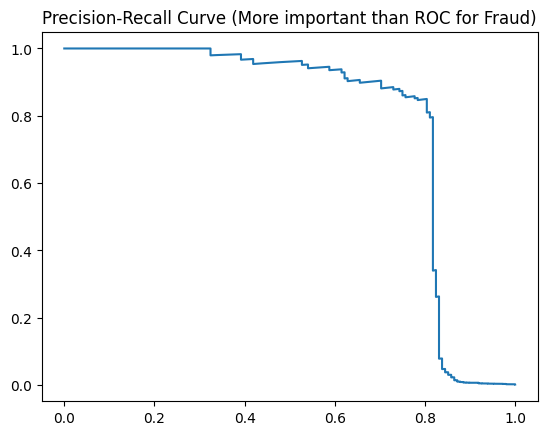

In [35]:
plt.plot(recall, precision)
plt.title('Precision-Recall Curve (More important than ROC for Fraud)')
plt.show()

In [22]:
from sklearn.metrics import classification_report,confusion_matrix
report_cat = classification_report(y_test, y_pred_cat)
cm_cat = confusion_matrix(y_test, y_pred_cat)
print('report:\n',report_cat)
print('cm:\n',cm_cat)

report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.67      0.78      0.72       148

    accuracy                           1.00     85443
   macro avg       0.84      0.89      0.86     85443
weighted avg       1.00      1.00      1.00     85443

cm:
 [[85238    57]
 [   32   116]]


In [23]:
x_addfeature = pd.concat([X_all,feature_add],axis=1)

In [24]:
from sklearn.model_selection import train_test_split
X_train_a, X_test_a, y_train_full_a, y_test_a = train_test_split(
    x_addfeature, y_true, test_size=0.3, random_state=42,stratify=y_true,
)

In [25]:
%%time
cat_features = creditcard.select_dtypes(include='object').columns.tolist()
from catboost import CatBoostClassifier
model_a = CatBoostClassifier(iterations=100, verbose=False,random_seed=42,auto_class_weights='Balanced',)
model_a.fit(X_train_a, y_train_full,cat_features = cat_features,)
y_proba_cat_a = model_a.predict_proba(X_test_a)[:, 1] 
y_pred_cat_a = model_a.predict(X_test_a)

CPU times: total: 24.8 s
Wall time: 1.74 s


In [26]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report,roc_auc_score

precision, recall, thresholds_pr = precision_recall_curve(y_test_a, y_proba_cat_a)
pr_auc = auc(recall, precision)
print(f"pr_auc: {pr_auc:.3f}")

auc_if = roc_auc_score(y_test_a, y_proba_cat_a)
print(f"AUC: {auc_if:.3f}")

pr_auc: 0.788
AUC: 0.949


In [27]:
from sklearn.metrics import classification_report,confusion_matrix
report_cat = classification_report(y_test_a, y_pred_cat_a)
cm_cat = confusion_matrix(y_test_a, y_pred_cat_a)
print('report:\n',report_cat)
print('cm:\n',cm_cat)

report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.68      0.82      0.74       148

    accuracy                           1.00     85443
   macro avg       0.84      0.91      0.87     85443
weighted avg       1.00      1.00      1.00     85443

cm:
 [[85238    57]
 [   27   121]]


In [28]:
# 针对此28万数据集，通过使用无监督学习：IF,LOF，半监督自训练，图论，显著提升PR_AUC：0.781==>0.814